<a href="https://colab.research.google.com/github/jcmachicao/IA_politicaspublicas/blob/main/RL___papa_optimizacion_venta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimizar la producción de papa con aprendizaje reforzado

José Carlos Machicao

In [23]:
import os
import pandas as pd
import torch

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
work_path = "drive/My Drive/00 2026_all/2026 Lab/"
os.listdir(work_path)

['Untitled0.ipynb', 'data_papa_1997_2021.xlsx']

In [10]:
data_papa = pd.read_excel(work_path + "data_papa_1997_2021.xlsx")
data_papa.shape

(21769, 6)

In [11]:
data_papa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21769 entries, 0 to 21768
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       21769 non-null  int64  
 1   mes        21769 non-null  int64  
 2   producto   21769 non-null  object 
 3   provincia  21333 non-null  object 
 4   volumen    21333 non-null  float64
 5   precio     21769 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1020.6+ KB


In [12]:
for col in data_papa.columns:
  print(col.center(50), data_papa[col].nunique())

                       year                        25
                       mes                         12
                     producto                      11
                    provincia                      121
                     volumen                       6872
                      precio                       222


In [13]:
data_papa["producto"].unique()

array(['Papa Color', 'Papa Blanca', 'Papa Huayro', 'Papa Amarilla',
       'Papa Yungay', 'Papa Peruanita', 'Papa Canchan', 'Papa Unica',
       'Papa Huamantanga', 'Papa Perricholi', 'Papa Negra Andina'],
      dtype=object)

# Task
The main goal is to develop a dynamic pricing strategy for agricultural products using Reinforcement Learning (RL). This involves defining an RL environment with appropriate state, action, and reward spaces, modeling product demand to simulate the environment, selecting and training an RL algorithm, and finally evaluating the performance of the trained pricing agent.

## Definir el Entorno RL

### Subtask:
Modelar el problema de la fijación de precios como un entorno de RL. Esto incluye la definición del espacio de estados, el espacio de acciones y la función de recompensa.


**Reasoning**:
The first instruction is to analyze the existing data to identify potential variables for the state space. Printing descriptive statistics and unique values for key categorical columns will help in this analysis.



In [14]:
print(data_papa.describe())
print("\nUnique values for producto:", data_papa['producto'].unique())
print("\nUnique values for provincia (top 10):", data_papa['provincia'].value_counts().head(10))
print("\nMissing values:\n", data_papa.isnull().sum())

               year           mes       volumen        precio
count  21769.000000  21769.000000  21333.000000  21769.000000
mean    2010.456659      6.436309    575.086887      0.870332
std        7.092194      3.390772   1413.341052      0.417333
min     1997.000000      1.000000      0.090000      0.280000
25%     2005.000000      3.000000     20.000000      0.600000
50%     2011.000000      7.000000     69.000000      0.750000
75%     2017.000000      9.000000    384.000000      1.040000
max     2021.000000     12.000000  16033.000000      3.320000

Unique values for producto: ['Papa Color' 'Papa Blanca' 'Papa Huayro' 'Papa Amarilla' 'Papa Yungay'
 'Papa Peruanita' 'Papa Canchan' 'Papa Unica' 'Papa Huamantanga'
 'Papa Perricholi' 'Papa Negra Andina']

Unique values for provincia (top 10): provincia
Huancayo       1397
Huanuco        1303
Pasco          1222
Huamanga       1035
Andahuaylas    1035
Tarma          1034
Ambo            951
Jauja           917
Arequipa        750
Junin  

### Definición del Espacio de Estados

El espacio de estados debe capturar la información relevante del mercado en un momento dado para que el agente de precios pueda tomar decisiones informadas. Basándonos en el análisis de `data_papa`, las siguientes variables son candidatas para el espacio de estados:

*   **`year`**: Representa el contexto temporal anual. Puede ser importante para tendencias a largo plazo.
*   **`mes`**: Indica la estacionalidad mensual. Los precios y volúmenes de productos agrícolas a menudo varían significativamente según el mes.
*   **`producto`**: La categoría específica de papa. Es crucial ya que la demanda y el precio son específicos para cada tipo de papa.
*   **`provincia`**: La ubicación geográfica. Los mercados locales pueden tener dinámicas de oferta y demanda diferentes.
*   **`volumen` (histórico o percibido)**: Aunque el problema es sobre 'definir' el precio, el volumen histórico o alguna proxy de la oferta/demanda actual es esencial para el estado. En un entorno real, esto podría ser el inventario disponible o la oferta general del mercado. Para el simulador, podemos considerar el 'volumen' observado en el pasado como parte del estado para entender cómo reaccionó el mercado a precios anteriores en situaciones similares.
*   **`precio` (histórico)**: El precio histórico previo o el precio promedio reciente puede ser un componente importante del estado, ya que la elasticidad de la demanda a menudo depende del precio base actual.

**Consideraciones para los valores faltantes:**

Se identificaron valores faltantes en `provincia` y `volumen`. Para el entorno RL, es crucial que el estado sea completo. Se propone el siguiente manejo:

*   **`provincia`**: Los 436 valores faltantes (aproximadamente el 2% del total) podrían ser tratados imputando con la moda o una categoría 'Desconocida' si la distribución no es muy sesgada. Alternativamente, si `provincia` es una variable crítica y los registros con NaN son pocos, podrían ser eliminados o el agente podría aprender a operar en un estado 'sin provincia definida'. Para empezar, la imputación con una nueva categoría como 'Desconocida' es un enfoque robusto.
*   **`volumen`**: Los 436 valores faltantes también representan un pequeño porcentaje. Dado que 'volumen' será clave para el modelo de demanda, la imputación con la media o mediana podría ser una opción si se asume que los valores faltantes son aleatorios. Sin embargo, si estos faltantes están relacionados con eventos específicos (por ejemplo, no se registró volumen), la imputación debe ser cuidadosa. Para el simulador inicial, podríamos imputar con la media condicional al producto y provincia, o considerar la eliminación si el modelado del volumen es muy sensible a datos precisos.

### Definición del Espacio de Acciones

El espacio de acciones (`A`) representa las decisiones que el agente de precios puede tomar en un estado dado. En este contexto, la acción principal es la **fijación de un precio para el producto en un momento y lugar específicos**.

Se pueden considerar dos enfoques principales para el espacio de acciones:

1.  **Espacio de Acciones Discreto**: El agente elige un precio de un conjunto predefinido de precios posibles. Por ejemplo:
    *   Un rango de precios discretizado en intervalos fijos (ej., `$0.50, $0.55, $0.60, ..., $3.00`).
    *   Porcentajes de ajuste sobre un precio base (ej., `-10%, -5%, 0%, +5%, +10%` sobre el precio promedio histórico).
    Este enfoque es m\u00e1s simple para implementar con algoritmos de RL basados en valores (como Q-learning, DQN).

2.  **Espacio de Acciones Continuo**: El agente elige un precio dentro de un rango continuo (ej., cualquier valor entre `$0.28` y `$3.32`, los m\u00ednimos y m\u00e1ximos observados).
    *   Este enfoque es m\u00e1s realista y permite una mayor flexibilidad en la fijaci\u00f3n de precios.
    *   Requiere algoritmos de RL m\u00e1s avanzados (como DDPG, SAC, PPO) que puedan manejar espacios de acciones continuos.

**Propuesta Inicial:** Para la fase inicial de desarrollo del entorno, se propone un **espacio de acciones discreto** para simplificar la implementaci\u00f3n y el entrenamiento del agente. Posteriormente, se podr\u00eda expandir a un espacio continuo.

*   **Rango de precios:** Basado en el `precio` observado en `data_papa`, el rango ir\u00eda de aproximadamente `$0.28` a `$3.32`.
*   **Discretizaci\u00f3n:** Podr\u00edamos definir un n\u00famero fijo de `N` acciones, distribuidas uniformemente en este rango, o centradas alrededor del precio promedio para cada `producto` y `provincia`.

### Definición de la Función de Recompensa

La función de recompensa (`R`) es fundamental en el aprendizaje por refuerzo, ya que guía al agente para lograr el objetivo deseado. En el contexto de la fijación de precios, el objetivo principal suele ser maximizar los ingresos o las ganancias. Por lo tanto, la recompensa debe reflejar directamente esta métrica.

**Propuesta para la Función de Recompensa Instantánea:**

Se propone que la recompensa instantánea (`r_t`) en cada paso de tiempo `t` sea el **ingreso total generado por el precio fijado y el volumen de ventas resultante**.

`r_t = precio_t * volumen_ventas_t`

Donde:
*   `precio_t` es el precio establecido por el agente en el paso `t`.
*   `volumen_ventas_t` es el volumen de ventas resultante de ese precio, según lo determinado por el modelo de demanda (simulador del entorno).

**Consideraciones Adicionales:**

*   **Ganancia vs. Ingreso**: Aunque el ingreso es un buen punto de partida, en un escenario más complejo, la recompensa podría ser la **ganancia**, restando los costos asociados a la producción, almacenamiento y venta del producto. Sin embargo, para la fase inicial y sin información explícita sobre costos en `data_papa`, el ingreso es una métrica directa y efectiva.
*   **Recompensas Retrasadas/Acumuladas**: El agente buscará maximizar la suma acumulada de estas recompensas instantáneas a lo largo del tiempo (recompensa descontada), lo que fomenta una política de precios que no solo busca beneficios a corto plazo sino que también considera la sostenibilidad y el crecimiento a largo plazo.
*   **Penalizaciones**: Se podrían introducir penalizaciones si el agente fija precios fuera de un rango razonable (por ejemplo, precios excesivamente bajos que no cubren costos, o precios tan altos que no generan ventas), pero esto puede ser explorado en fases avanzadas.

## Modelar la Demanda (Simulador del Entorno)

### Subtask:
Desarrollar un modelo de demanda que simule cómo el volumen de ventas reacciona a un precio propuesto, considerando otras variables de estado. Este modelo actuará como el entorno con el que interactúa el agente de RL.


**Reasoning**:
I will visualize the relationships between `precio`, `volumen`, `producto`, and `provincia` using scatter plots and box plots to understand their distributions and interactions, which is the first instruction of the subtask.



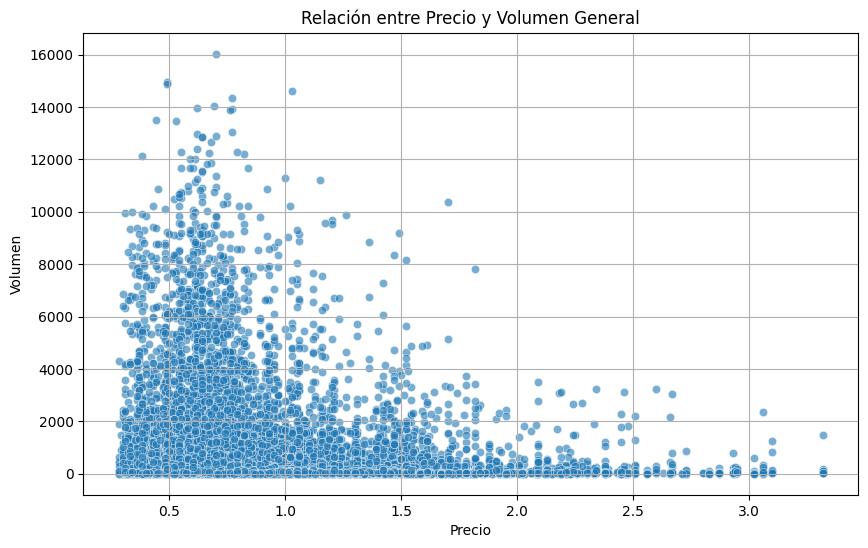

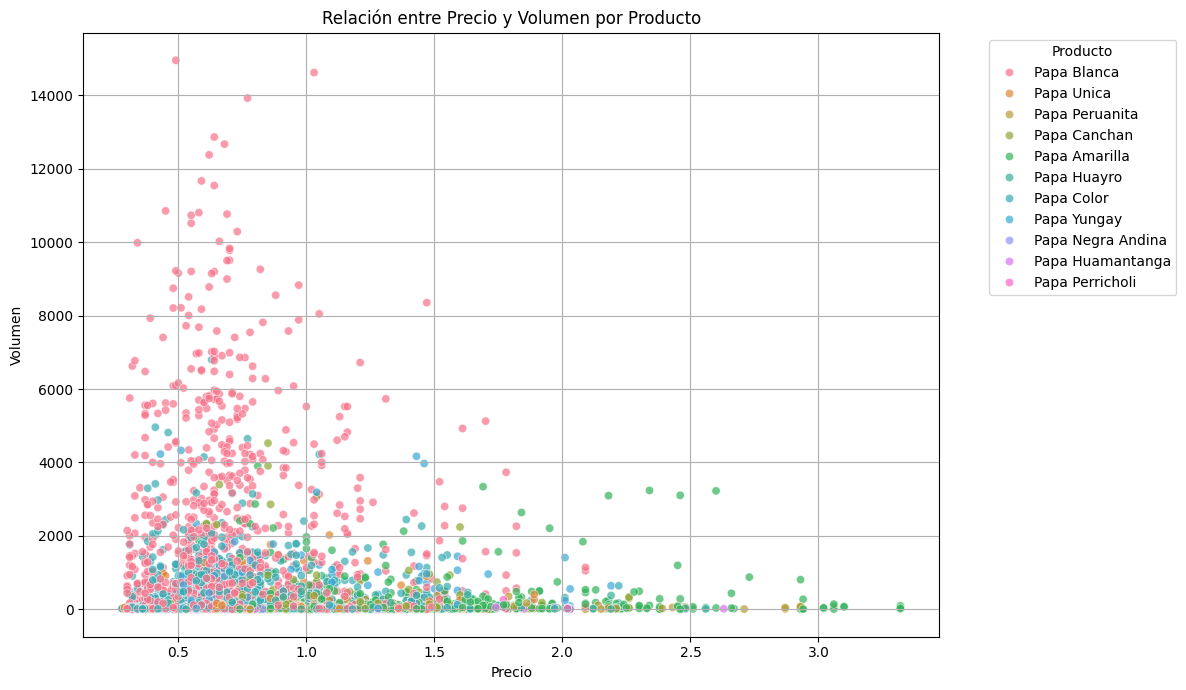

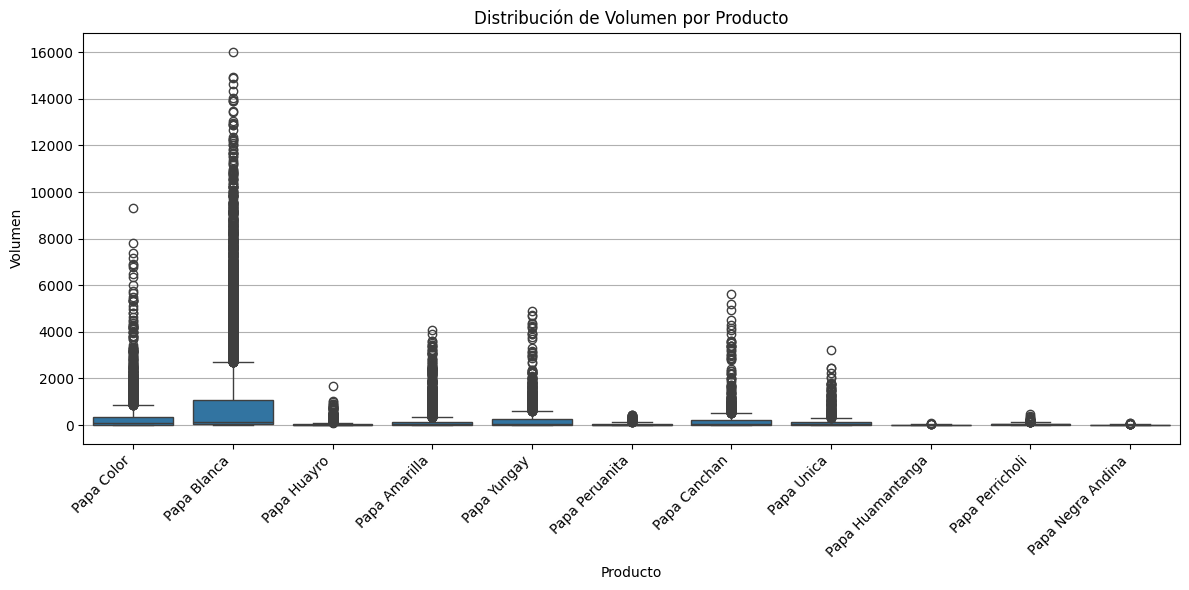

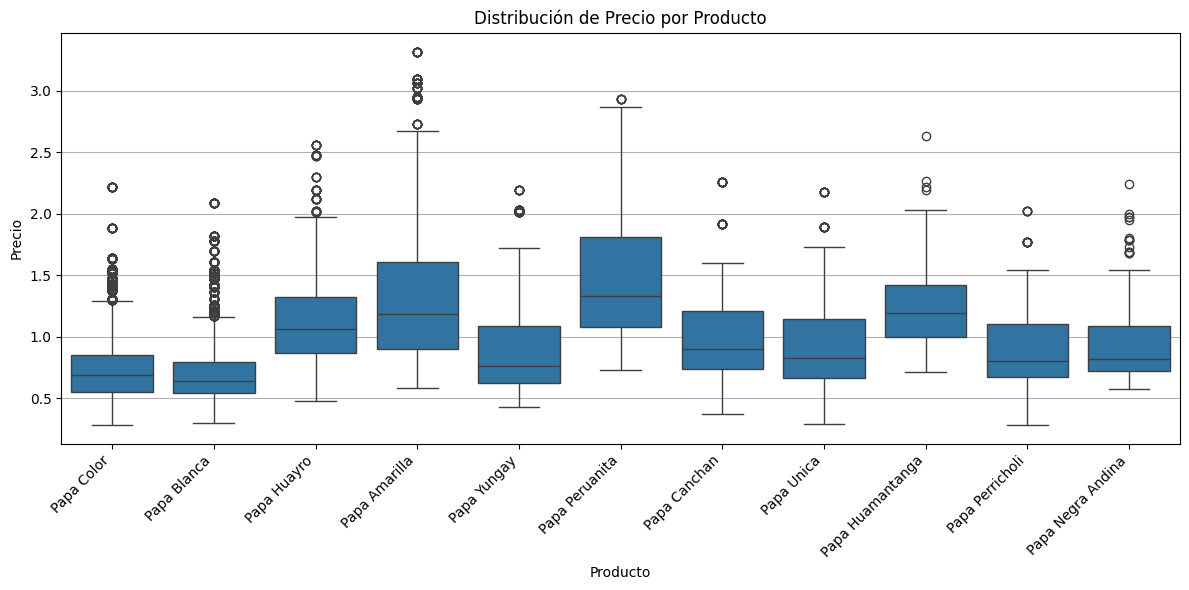


Correlation Matrix:
           precio   volumen      year       mes
precio   1.000000 -0.112122  0.409974  0.047895
volumen -0.112122  1.000000 -0.061071  0.000771
year     0.409974 -0.061071  1.000000 -0.019448
mes      0.047895  0.000771 -0.019448  1.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship between precio and volumen
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_papa, x='precio', y='volumen', alpha=0.6)
plt.title('Relación entre Precio y Volumen General')
plt.xlabel('Precio')
plt.ylabel('Volumen')
plt.grid(True)
plt.show()

# Visualize the relationship between precio and volumen by producto (sampling for clarity if needed)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=data_papa.sample(n=5000, random_state=42) if len(data_papa) > 5000 else data_papa,
                x='precio', y='volumen', hue='producto', alpha=0.7)
plt.title('Relación entre Precio y Volumen por Producto')
plt.xlabel('Precio')
plt.ylabel('Volumen')
plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Box plot of volumen by producto
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_papa, x='producto', y='volumen')
plt.title('Distribución de Volumen por Producto')
plt.xlabel('Producto')
plt.ylabel('Volumen')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Box plot of precio by producto
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_papa, x='producto', y='precio')
plt.title('Distribución de Precio por Producto')
plt.xlabel('Producto')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Display the correlation matrix to see numerical relationships
correlation_matrix = data_papa[['precio', 'volumen', 'year', 'mes']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)





**Reasoning**:
Handle missing values in `provincia` by filling with 'Desconocida' and in `volumen` by filling with the mean of the column, which are necessary steps before modeling demand.



In [16]:
print("Missing values before imputation:")
print(data_papa.isnull().sum())

# Impute missing 'provincia' values with 'Desconocida'
data_papa['provincia'].fillna('Desconocida', inplace=True)

# Impute missing 'volumen' values with the mean of the column
data_papa['volumen'].fillna(data_papa['volumen'].mean(), inplace=True)

print("\nMissing values after imputation:")
print(data_papa.isnull().sum())


Missing values before imputation:
year           0
mes            0
producto       0
provincia    436
volumen      436
precio         0
dtype: int64

Missing values after imputation:
year         0
mes          0
producto     0
provincia    0
volumen      0
precio       0
dtype: int64


/tmp/ipykernel_3157/462814524.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_papa['provincia'].fillna('Desconocida', inplace=True)
/tmp/ipykernel_3157/462814524.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

**Reasoning**:
I am modifying the previous code to address the `FutureWarning` by replacing `inplace=True` with direct assignment to the DataFrame columns, ensuring cleaner and more future-proof code for handling missing values. Then, to continue building the demand model, I will create interaction terms between `precio` and categorical variables as per the instructions.



In [17]:
print("Missing values before imputation:")
print(data_papa.isnull().sum())

# Impute missing 'provincia' values with 'Desconocida' without inplace=True
data_papa['provincia'] = data_papa['provincia'].fillna('Desconocida')

# Impute missing 'volumen' values with the mean of the column without inplace=True
data_papa['volumen'] = data_papa['volumen'].fillna(data_papa['volumen'].mean())

print("\nMissing values after imputation:")
print(data_papa.isnull().sum())

# Create interaction terms
# Interaction between precio and producto
for prod in data_papa['producto'].unique():
    data_papa[f'precio_x_{prod.replace(" ", "_")}'] = data_papa['precio'] * (data_papa['producto'] == prod)

# Interaction between precio and provincia (using one-hot encoding for simplicity here)
# For a large number of provinces, this might create too many features. Consider feature selection or grouping.
# For now, we'll create interactions for the top 10 provinces based on count (as seen in earlier analysis)
# First, identify top 10 provinces to limit the number of interaction terms
top_10_provincias = data_papa['provincia'].value_counts().head(10).index.tolist()

for prov in top_10_provincias:
    data_papa[f'precio_x_{prov.replace(" ", "_")}'] = data_papa['precio'] * (data_papa['provincia'] == prov)

# Display the first few rows with new interaction features and their shapes
print("\nDataFrame head with new interaction features:")
print(data_papa.head())
print("\nDataFrame shape after adding interaction features:")
print(data_papa.shape)

Missing values before imputation:
year         0
mes          0
producto     0
provincia    0
volumen      0
precio       0
dtype: int64

Missing values after imputation:
year         0
mes          0
producto     0
provincia    0
volumen      0
precio       0
dtype: int64

DataFrame head with new interaction features:
   year  mes       producto provincia  volumen  precio  precio_x_Papa_Color  \
0  2011    6     Papa Color   Abancay     31.0    0.77                 0.77   
1  2011    5    Papa Blanca   Abancay     47.0    0.64                 0.00   
2  2017    7    Papa Huayro   Abancay      3.0    1.30                 0.00   
3  2003    7  Papa Amarilla   Abancay     27.7    0.74                 0.00   
4  2003    8     Papa Color   Abancay     27.3    0.68                 0.68   

   precio_x_Papa_Blanca  precio_x_Papa_Huayro  precio_x_Papa_Amarilla  ...  \
0                  0.00                   0.0                    0.00  ...   
1                  0.64                   0.0   

**Reasoning**:
I will encode categorical variables, split the data, and train a regression model to predict `volumen`, which directly addresses the core of the demand modeling subtask.



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prepare data for modeling
# Select features for the demand model
features = ['year', 'mes', 'precio'] + \
           [col for col in data_papa.columns if col.startswith('precio_x_')]

# One-hot encode 'producto' and 'provincia'
data_papa_encoded = pd.get_dummies(data_papa, columns=['producto', 'provincia'], drop_first=True)

# Update features list with encoded categorical columns
# Ensure all relevant columns are included
encoded_product_cols = [col for col in data_papa_encoded.columns if col.startswith('producto_')]
encoded_provincia_cols = [col for col in data_papa_encoded.columns if col.startswith('provincia_')]

features.extend(encoded_product_cols)
features.extend(encoded_provincia_cols)

# Ensure only existing features are selected
features = [f for f in features if f in data_papa_encoded.columns]

X = data_papa_encoded[features]
y = data_papa_encoded['volumen']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Train a Random Forest Regressor model
# RandomForest is a good choice for its robustness and ability to capture non-linear relationships
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nDemand Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Feature Importances:")
print(feature_importances.head(10))


Shape of X_train: (17415, 155)
Shape of X_test: (4354, 155)

Demand Model Evaluation:
Mean Squared Error (MSE): 211469.67
Root Mean Squared Error (RMSE): 459.86
R-squared (R2): 0.89

Top 10 Feature Importances:
mes                     0.343067
year                    0.131363
precio_x_Huanuco        0.084189
precio_x_Papa_Blanca    0.072799
precio_x_Huamanga       0.064790
precio_x_Huancayo       0.056819
provincia_Huanuco       0.053313
producto_Papa Blanca    0.024981
provincia_Huaral        0.018933
precio                  0.018868
dtype: float64


## Diseñar el Espacio de Estados

### Subtask:
Identificar las características de los datos que representarán el 'estado' actual del mercado para el agente de RL.


### Definición Final del Espacio de Estados

Basándonos en el análisis exploratorio y en las características utilizadas para el modelo de demanda, el espacio de estados (`S`) para el agente de Reinforcement Learning se define por la siguiente combinación de variables, buscando proporcionar una representación rica y suficiente del entorno de mercado en cualquier momento dado:

**Variables Numéricas Directas:**
*   `year`: Representa la tendencia temporal a largo plazo y el contexto anual.
*   `mes`: Captura la estacionalidad mensual, crucial para productos agrícolas.
*   `precio`: El precio actual o histórico que el agente está considerando o ha observado. Este es dinámico y parte fundamental del estado.

**Variables Categóricas Codificadas (One-Hot Encoding):**
Para `producto` y `provincia`, que son variables categóricas nominales, se utilizan sus representaciones one-hot encoded. Esto permite que el modelo distinga entre los diferentes tipos de productos y ubicaciones sin imponer una ordenación artificial.
*   `producto_<nombre_producto>`: Indicadores binarios para cada tipo de papa (ej., `producto_Papa Blanca`, `producto_Papa Color`, etc.).
*   `provincia_<nombre_provincia>`: Indicadores binarios para cada provincia (o las más relevantes, como se usó para el modelo de demanda, ej., `provincia_Huanuco`, `provincia_Huancayo`, etc.).

**Términos de Interacción:**
Para capturar relaciones no lineales y específicas del contexto, se han creado términos de interacción entre el precio y las variables categóricas. Estos son particularmente importantes ya que la sensibilidad al precio (`volumen`) probablemente varía significativamente según el tipo de producto y la ubicación.
*   `precio_x_<nombre_producto>`: Interacción entre el precio y cada tipo de producto. Esto permite al agente entender cómo el precio afecta la demanda de un producto específico.
*   `precio_x_<nombre_provincia>`: Interacción entre el precio y las provincias principales. Esto ayuda a modelar cómo el precio influye en la demanda en mercados geográficos específicos.

**Componentes del Estado (`s_t`):**
En cada paso de tiempo `t`, el estado `s_t` será un vector que incluye:
`[year_t, mes_t, precio_t, producto_Papa Blanca_t, ..., provincia_Huanuco_t, ..., precio_x_Papa_Blanca_t, ..., precio_x_Huanuco_t, ...]`

Este conjunto de características proporciona al agente una visión completa de:
1.  **Contexto Temporal**: Año y mes para capturar tendencias y estacionalidades.
2.  **Identidad del Producto**: Qué producto específico se está "preciando".
3.  **Localización del Mercado**: Dónde se está "preciando" el producto.
4.  **Nivel de Precio Actual/Considerado**: El precio base para la toma de decisiones.
5.  **Sensibilidad al Precio Específica**: Cómo el precio interactúa con el producto y la provincia para influir potencialmente en la demanda.

La inclusión de `volumen` (histórico o percibido) como parte del estado, que se mencionó en la definición inicial del entorno RL, se realizará indirectamente a través de la respuesta del modelo de demanda. El modelo de demanda predice el volumen, y este resultado es lo que el agente observará como parte de la recompensa y lo que se usará para construir el siguiente estado si fuera necesario integrar un `volumen_pasado` en el estado.



## Definir el Espacio de Acciones

### Subtask:
Especificar las acciones que el agente de RL puede tomar, definiendo un espacio de acciones discreto para la fijación de precios.


**Reasoning**:
Determine the minimum and maximum 'precio' from the `data_papa` DataFrame, then create a discrete set of 10 uniformly distributed price points within this range to define the action space for the RL agent, as per the instructions.



In [19]:
import numpy as np

# 1. Determine the minimum and maximum precio
min_precio = data_papa['precio'].min()
max_precio = data_papa['precio'].max()

print(f"Minimum observed price: {min_precio:.2f}")
print(f"Maximum observed price: {max_precio:.2f}")

# 2. Create a discrete set of price actions (e.g., 10 distinct price points)
# using np.linspace to get uniformly distributed points
num_actions = 10
action_space = np.linspace(min_precio, max_precio, num_actions)

# 3. Store and display this discrete set of prices
print(f"\nDiscrete Action Space (Price points):\n{action_space.round(2)}")


Minimum observed price: 0.28
Maximum observed price: 3.32

Discrete Action Space (Price points):
[0.28 0.62 0.96 1.29 1.63 1.97 2.31 2.64 2.98 3.32]


## Establecer la Función de Recompensa

### Subtask:
Diseñar una función de recompensa que motive al agente a lograr el objetivo deseado. Por ejemplo, la recompensa podría ser el 'ingreso total' (precio * volumen de ventas) o la 'ganancia' (ingreso - costos). Es crucial que esta función refleje el éxito de la decisión de precio.


### Función de Recompensa Final

La función de recompensa es el pilar central que guía el aprendizaje de nuestro agente de Reinforcement Learning. Para este problema de fijación de precios dinámica, hemos definido la recompensa instantánea (`r_t`) en cada paso de tiempo `t` como el **ingreso total generado** por la decisión de precio del agente:

`r_t = precio_t * volumen_ventas_t`

Donde:
*   `precio_t` es el precio establecido por el agente en el paso `t`.
*   `volumen_ventas_t` es el volumen de ventas resultante de ese precio, el cual será determinado por el modelo de demanda que hemos desarrollado (actuando como el simulador del entorno).

**Racional y Guía del Agente:**
La elección del **ingreso total** como recompensa principal se alinea directamente con el objetivo de **maximizar los beneficios económicos** de la estrategia de precios. Al buscar maximizar esta recompensa en cada interacción, el agente aprenderá una política de precios que equilibre la "elasticidad" del precio (cómo el volumen de ventas responde a los cambios de precio) para generar los mayores ingresos posibles. El agente, a través de prueba y error y el algoritmo de RL, ajustará sus decisiones de precio en diferentes estados (combinaciones de año, mes, producto, provincia, etc.) para encontrar las configuraciones que históricamente (según el simulador) condujeron a un mayor `precio * volumen_ventas`.

**Mejoras Futuras:**
Aunque el ingreso total es una métrica sólida para empezar, es importante reconocer que una visión más completa de la optimización empresarial a menudo implica la **ganancia** (`ingreso - costos`). En futuras iteraciones o escenarios más avanzados, podríamos enriquecer esta función de recompensa restando los costos asociados (producción, logística, marketing, etc.) para motivar al agente a una verdadera maximización de la ganancia. Sin embargo, para esta fase inicial del proyecto y dada la información disponible en `data_papa`, el ingreso es una métrica directa y eficaz para establecer un agente de precios funcional.

## Seleccionar el Algoritmo de RL

### Subtask:
Elegir un algoritmo de RL apropiado que pueda aprender la política óptima de fijación de precios interactuando con el modelo de demanda.


### Selección del Algoritmo de Reinforcement Learning

Dado que hemos optado por un **espacio de acciones discreto** (un conjunto finito de precios que el agente puede elegir), los algoritmos de Reinforcement Learning basados en valores son los más adecuados y de implementación más directa para esta fase inicial del proyecto.

#### Algoritmo Elegido: Q-Learning

**Q-Learning** es un algoritmo de aprendizaje por refuerzo *off-policy* y sin modelo que aprende una función de valor de acción-estado (`Q-function`). Esta función `Q(s, a)` estima el valor esperado de tomar una acción `a` en un estado `s` y luego seguir la política óptima. La elección de Q-learning se justifica por las siguientes razones:

1.  **Espacio de Acciones Discreto**: Q-learning está diseñado para trabajar eficientemente con espacios de acciones discretos, lo cual se alinea perfectamente con nuestra definición actual del espacio de precios.
2.  **Simplicidad y Robustez**: Es relativamente sencillo de entender e implementar, y es conocido por su robustez en una amplia gama de problemas.
3.  **Base para Algoritmos Más Avanzados**: Sirve como una excelente base para comprender los conceptos de RL antes de pasar a algoritmos más complejos como Deep Q-Networks (DQN) si el espacio de estados crece demasiado.

#### ¿Cómo interactuará Q-Learning con el entorno?

El agente de Q-learning interactuará con nuestro simulador de demanda de la siguiente manera:

1.  **Observación del Estado (`s_t`)**: En cada paso de tiempo `t`, el agente observará el estado actual del mercado, que consistirá en `year`, `mes`, `precio` (histórico o de referencia), `producto`, `provincia`, y los términos de interacción correspondientes.
2.  **Selección de la Acción (`a_t`)**: Basándose en su tabla Q (o una aproximación de la función Q) y una política de exploración-explotación (por ejemplo, ε-greedy), el agente seleccionará un precio (`a_t`) del `action_space` discreto.
3.  **Interacción con el Simulador**: El precio seleccionado (`a_t`) se pasará al modelo de demanda (simulador del entorno), que predecirá el `volumen_ventas_t` resultante, dadas las otras variables del estado `s_t`.
4.  **Recepción de la Recompensa (`r_t`)**: El simulador devolverá la recompensa `r_t`, calculada como `precio_t * volumen_ventas_t`.
5.  **Transición al Nuevo Estado (`s_{t+1}`)**: Se generará un nuevo estado `s_{t+1}` (que reflejará los cambios temporales o de contexto, y posiblemente el precio elegido en `t`).
6.  **Actualización de la Función Q**: El agente utilizará la recompensa `r_t` y el nuevo estado `s_{t+1}` para actualizar su conocimiento sobre la función Q, aprendiendo así qué acciones son más beneficiosas en cada estado. La regla de actualización de Q-learning es:

    `Q(s_t, a_t) = Q(s_t, a_t) + α * [r_t + γ * max_a' Q(s_{t+1}, a') - Q(s_t, a_t)]`

    Donde `α` es la tasa de aprendizaje y `γ` es el factor de descuento.

Este proceso iterativo permitirá al agente construir una política de precios óptima a lo largo del tiempo, maximizando la recompensa acumulada (ingreso total) a largo plazo.

## Estrategia de Entrenamiento

### Subtask:
Describir cómo el agente aprendería: el agente propondría un precio (acción), el modelo de demanda simularía el volumen resultante, se calcularía la recompensa, y el agente actualizaría su política para maximizar la recompensa acumulada a lo largo del tiempo.


**Reasoning**:
The first instruction is to implement the RL environment class. This involves encapsulating the demand model, state space, and action space, and defining `reset()` and `step()` methods.



In [20]:
import numpy as np
import pandas as pd

class RLEnvironment:
    def __init__(self, demand_model, action_space, data_papa_original, data_papa_encoded, state_features, products, provinces, top_10_provincias):
        self.demand_model = demand_model
        self.action_space = action_space
        self.data_papa_original = data_papa_original  # Used to get original categorical names for Q-state mapping
        self.data_papa_encoded = data_papa_encoded    # Used to sample full feature rows for model input
        self.state_features = state_features          # Column names for the demand model input (X)
        self.products = products                      # List of unique product names
        self.provinces = provinces                    # List of all unique province names
        self.top_10_provincias = top_10_provincias    # List of top 10 provinces for grouping

        # Mappings for the simplified Q-table state representation
        self.product_to_idx = {p: i for i, p in enumerate(self.products)}
        self.province_group_to_idx = {p: i for i, p in enumerate(self.top_10_provincias + ['Desconocida', 'Other'])}
        self.mes_to_idx = {m: i for i, m in enumerate(range(1, 13))}

        self.current_full_context_row = None  # Stores the pandas Series for the current scenario (from data_papa_encoded)
        self.current_q_state = None           # The simplified state tuple for the Q-table

    def _get_q_state_tuple(self, original_row_context):
        # Maps a full original context row to a simplified, hashable state for the Q-table
        product_name = original_row_context['producto']
        mes = original_row_context['mes']
        province_name = original_row_context['provincia']

        # Group provinces: top 10, 'Desconocida', or 'Other'
        if province_name in self.top_10_provincias:
            province_group = province_name
        elif province_name == 'Desconocida':
            province_group = 'Desconocida'
        else:
            province_group = 'Other'

        return (
            self.product_to_idx[product_name],
            self.province_group_to_idx[province_group],
            self.mes_to_idx[mes]
        )

    def reset(self):
        # Select a random row index from the encoded data to define a new scenario
        random_idx = np.random.choice(self.data_papa_encoded.index)
        self.current_full_context_row = self.data_papa_encoded.loc[random_idx].copy()

        # Get the corresponding original row to extract actual product/province names for Q-state mapping
        original_context_row = self.data_papa_original.loc[random_idx].copy()
        self.current_q_state = self._get_q_state_tuple(original_context_row)

        return self.current_q_state

    def step(self, action_idx):
        chosen_price = self.action_space[action_idx]

        # Prepare input for the demand model by modifying the current full context row
        model_input_row = self.current_full_context_row.copy()
        model_input_row['precio'] = chosen_price

        # Get the original product and province names for accurate interaction term calculation
        original_product_name = self.data_papa_original.loc[self.current_full_context_row.name, 'producto']
        original_provincia_name = self.data_papa_original.loc[self.current_full_context_row.name, 'provincia']

        # Re-calculate interaction terms based on the new chosen_price
        for prod_name in self.products:
            col_name = f'precio_x_{prod_name.replace(" ", "_")}'
            if col_name in model_input_row.index:
                is_this_product = (original_product_name == prod_name)
                model_input_row[col_name] = chosen_price * is_this_product

        for prov_name in self.top_10_provincias:
            col_name = f'precio_x_{prov_name.replace(" ", "_")}'
            if col_name in model_input_row.index:
                is_this_province = (original_provincia_name == prov_name)
                model_input_row[col_name] = chosen_price * is_this_province

        # Select only the features the model was trained on, in the correct order
        X_predict = pd.DataFrame([model_input_row[self.state_features].values], columns=self.state_features)

        predicted_volumen = self.demand_model.predict(X_predict)[0]
        reward = chosen_price * predicted_volumen

        # For this simple episodic setting, the episode ends after one decision.
        # The next state is effectively handled by the next call to reset().
        done = True
        next_q_state = None  # No meaningful next Q-state in a single-step episode for direct chaining

        return next_q_state, reward, done, {}

# Instantiate the RL environment
unique_products = data_papa['producto'].unique().tolist()
unique_provinces_all = data_papa['provincia'].unique().tolist()

env = RLEnvironment(
    demand_model=model,
    action_space=action_space,
    data_papa_original=data_papa,
    data_papa_encoded=data_papa_encoded,
    state_features=features,
    products=unique_products,
    provinces=unique_provinces_all,
    top_10_provincias=top_10_provincias
)

print("RL Environment class defined and instantiated successfully.")

RL Environment class defined and instantiated successfully.


### Estrategia de Entrenamiento con Q-Learning

La estrategia de entrenamiento del agente Q-Learning se centrará en permitirle interactuar repetidamente con el entorno simulado (nuestro modelo de demanda) a lo largo de muchos episodios. A través de esta interacción, el agente acumulará experiencia y actualizará su tabla Q, aprendiendo así la política óptima de fijación de precios.

**Componentes Clave de la Estrategia:**

1.  **Inicialización de la Tabla Q**: La tabla Q almacenará los valores de Q para cada par estado-acción. Dado que nuestro espacio de estados es una tupla de índices (producto, grupo de provincia, mes), y nuestro espacio de acciones es discreto, la tabla Q se inicializará con ceros o valores aleatorios pequeños. Su estructura será un diccionario anidado o similar para manejar la escasez de estados y permitir el acceso eficiente.
    *   `Q[estado][acción_idx] = valor_Q`

2.  **Parámetros de Aprendizaje (Hiperparámetros)**:
    *   **Tasa de Aprendizaje (`alpha` o `α`)**: Determina en qué medida la información nueva anula la información antigua. Un valor de `α = 0` hace que el agente no aprenda nada, mientras que `α = 1` hace que solo considere la información más reciente. Típicamente, un valor entre 0.1 y 0.9 es efectivo.
    *   **Factor de Descuento (`gamma` o `γ`)**: Cuánto valen las recompensas futuras en el presente. Un `γ = 0` hace que el agente sea "oportunista" (solo le importan las recompensas inmediatas), mientras que un `γ = 1` lo hace "visionario" (valora por igual las recompensas futuras y actuales). Comúnmente, se usa un valor cercano a 1 (ej., 0.9 o 0.99).
    *   **Tasa de Exploración (`epsilon` o `ε`)**: Controla el equilibrio entre exploración (probar acciones nuevas) y explotación (elegir la mejor acción conocida). Con una probabilidad `ε`, el agente elige una acción aleatoria; con `1 - ε`, elige la acción con el valor Q más alto para el estado actual. `ε` generalmente disminuye con el tiempo para pasar de una fase de alta exploración a una de alta explotación.

3.  **Bucle de Entrenamiento por Episodios**:
    *   El entrenamiento se realizará durante un número fijo de `episodios` (ej., 10,000 o más).
    *   **Para cada episodio:**
        *   **Resetear el Entorno**: El entorno (`env.reset()`) se reinicia para obtener un nuevo `estado_q` inicial (un escenario aleatorio de `producto`, `provincia`, `mes`).
        *   **Bucle de un Solo Paso**: Para este problema de decisión de precio único por escenario, cada "episodio" consistirá en un solo paso:
            *   **Selección de Acción (`epsilon-greedy`)**: El agente decide si explora (elige una acción de precio aleatoria) o explota (elige el precio con el valor Q más alto para el `estado_q` actual).
            *   **Realizar Acción**: La acción (`acción_idx`) se envía al entorno (`env.step(acción_idx)`), que, usando el modelo de demanda, calcula el `volumen_ventas` y devuelve la `recompensa` (ingreso).
            *   **Actualización de la Tabla Q**: Utilizando la ecuación de actualización de Q-Learning:
                `Q[estado_q][acción_idx] = Q[estado_q][acción_idx] + α * [recompensa + γ * max_a' Q[s_final, a'] - Q[estado_q][acción_idx]]`
                Dado que cada episodio es de un solo paso y `done` es `True` inmediatamente, `s_final` no tiene un valor subsiguiente para `max_a' Q[s_final, a']`, por lo que este término se considerará 0. La actualización se simplifica a: `Q[estado_q][acción_idx] = Q[estado_q][acción_idx] + α * [recompensa - Q[estado_q][acción_idx]]`.

4.  **Decaimiento de Épsilon**: La tasa de exploración `ε` disminuirá progresivamente a lo largo de los episodios. Esto permite que el agente explore ampliamente al principio del entrenamiento y luego se enfoque en explotar el conocimiento aprendido a medida que se vuelve más "experto".

Esta estrategia permitirá al agente aprender una política que maximice el ingreso acumulado a largo plazo, adaptando sus decisiones de precio a las características específicas del producto, la provincia y el mes.

**Reasoning**:
I need to initialize the Q-table, which will store Q-values for each state-action pair, and set up the Q-Learning hyperparameters as described in the training strategy markdown block. This involves creating a dictionary for the Q-table and defining `alpha`, `gamma`, `epsilon`, and `num_episodes`.



In [21]:
import random
from collections import defaultdict

# 1. Initialize Q-table
# The Q-table will store Q-values for each state-action pair.
# States are tuples: (product_idx, province_group_idx, mes_idx)
# Actions are indices corresponding to the action_space array.
# Using defaultdict(lambda: np.zeros(len(action_space))) allows for dynamic creation
# of state entries with a default array of zeros for action values.
Q_table = defaultdict(lambda: np.zeros(len(action_space)))

# 2. Define Learning Parameters (Hyperparameters)
alpha = 0.1   # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0 # Exploration rate (starts high for exploration)

# Epsilon decay parameters
epsilon_decay_rate = 0.001 # Rate at which epsilon decreases
min_epsilon = 0.01         # Minimum epsilon value

# Training parameters
num_episodes = 100000 # Number of episodes to train the agent

print("Q-table initialized and hyperparameters defined.")
print(f"Initial alpha: {alpha}, gamma: {gamma}, epsilon: {epsilon}")
print(f"Number of actions: {len(action_space)}")

Q-table initialized and hyperparameters defined.
Initial alpha: 0.1, gamma: 0.99, epsilon: 1.0
Number of actions: 10


**Reasoning**:
Implement the Q-Learning training loop, including epsilon-greedy action selection and Q-table update.



In [22]:
rewards_per_episode = []

for episode in range(num_episodes):
    # 1. Reset the environment to get a new initial Q-state
    state_q = env.reset()

    # 2. Choose an action using epsilon-greedy policy
    if random.uniform(0, 1) < epsilon: # Explore: choose a random action
        action_idx = random.randrange(len(action_space))
    else: # Exploit: choose the action with the highest Q-value for the current state
        action_idx = np.argmax(Q_table[state_q])

    # 3. Perform the action and get the reward
    # In this single-step episodic environment, next_q_state will be None, and done will be True
    next_q_state, reward, done, _ = env.step(action_idx)

    # 4. Update Q-table
    # Since each episode is a single step (done=True immediately), there is no next state value to consider
    # The update rule simplifies to: Q[state_q][action_idx] = Q[state_q][action_idx] + alpha * [reward - Q[state_q][action_idx]]
    Q_table[state_q][action_idx] = Q_table[state_q][action_idx] + alpha * (reward - Q_table[state_q][action_idx])

    rewards_per_episode.append(reward)

    # 5. Epsilon decay
    epsilon = max(min_epsilon, epsilon - epsilon_decay_rate)

    # Optional: Print progress
    if (episode + 1) % 10000 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, Epsilon: {epsilon:.4f}, Average Reward (last 10000): {np.mean(rewards_per_episode[-10000:]):.2f}")

print("\nTraining complete!")

Episode 10000/100000, Epsilon: 0.0100, Average Reward (last 10000): 808.63
Episode 20000/100000, Epsilon: 0.0100, Average Reward (last 10000): 892.57
Episode 30000/100000, Epsilon: 0.0100, Average Reward (last 10000): 917.95
Episode 40000/100000, Epsilon: 0.0100, Average Reward (last 10000): 898.09
Episode 50000/100000, Epsilon: 0.0100, Average Reward (last 10000): 925.91
Episode 60000/100000, Epsilon: 0.0100, Average Reward (last 10000): 919.12
Episode 70000/100000, Epsilon: 0.0100, Average Reward (last 10000): 977.35
Episode 80000/100000, Epsilon: 0.0100, Average Reward (last 10000): 1016.11
Episode 90000/100000, Epsilon: 0.0100, Average Reward (last 10000): 998.63
Episode 100000/100000, Epsilon: 0.0100, Average Reward (last 10000): 1057.20

Training complete!


# Task
The main goal is to develop a dynamic pricing strategy for agricultural products using Reinforcement Learning (RL). This involves defining an RL environment with appropriate state, action, and reward spaces, modeling product demand to simulate the environment, selecting and training an RL algorithm, and finally evaluating the performance of the trained pricing agent.

## Evaluar el Rendimiento del Agente RL

### Subtask:
Evaluar la política de precios aprendida por el agente de RL en diferentes escenarios. Esto puede incluir probar el agente en datos históricos no utilizados para el entrenamiento, o simular nuevos escenarios de mercado para ver cómo se comporta.


**Reasoning**:
Implement a function that takes a state (product, province group, month) and the Q-table, and returns the optimal action (price) and its corresponding Q-value. This function will represent the learned policy of the agent.



In [24]:
def get_optimal_price_from_q_table(Q_table, state_q, action_space):
    """
    Retrieves the optimal price for a given state from the Q-table.

    Args:
        Q_table (defaultdict): The trained Q-table.
        state_q (tuple): A tuple representing the state (product_idx, province_group_idx, mes_idx).
        action_space (np.ndarray): The discrete array of possible prices.

    Returns:
        tuple: (optimal_price, optimal_q_value) or (None, None) if state not in Q_table.
    """
    if state_q in Q_table:
        # Get the Q-values for all actions in the given state
        q_values_for_state = Q_table[state_q]
        # Find the index of the action with the maximum Q-value
        optimal_action_idx = np.argmax(q_values_for_state)
        # Get the optimal price from the action space
        optimal_price = action_space[optimal_action_idx]
        # Get the Q-value for the optimal action
        optimal_q_value = q_values_for_state[optimal_action_idx]
        return optimal_price, optimal_q_value
    else:
        # If the state has not been encountered, return None
        return None, None

print("Function 'get_optimal_price_from_q_table' defined.")

Function 'get_optimal_price_from_q_table' defined.


**Reasoning**:
I will evaluate the performance of the trained agent by simulating its optimal pricing policy on a set of test scenarios and calculating the average reward. This directly addresses the evaluation aspect of the subtask.



In [25]:
eval_rewards = []
num_eval_episodes = 1000 # Number of scenarios to evaluate the agent on

print(f"\nEvaluating agent on {num_eval_episodes} scenarios...")

for _ in range(num_eval_episodes):
    # Reset the environment to get a new random scenario (state_q)
    # The reset method of our env already samples a random row and sets current_q_state
    state_q = env.reset()

    # Get the optimal price from the Q-table for the current state_q
    # The 'state_q' here is the simplified tuple (product_idx, province_group_idx, mes_idx)
    optimal_price, optimal_q_value = get_optimal_price_from_q_table(Q_table, state_q, action_space)

    if optimal_price is not None:
        # Find the index of the optimal price in the action_space
        optimal_action_idx = np.where(action_space == optimal_price)[0][0]

        # Simulate the step with the optimal action to get the reward
        # In our env, step() expects the action_idx, not the price itself
        _, reward, _, _ = env.step(optimal_action_idx)
        eval_rewards.append(reward)
    else:
        # If the state was not encountered during training, it might not be in the Q_table.
        # In such cases, we could choose a default action or skip, but for now, we'll note 0 reward.
        # A more sophisticated approach might involve a fallback policy.
        eval_rewards.append(0) # Or handle this differently if desired

if eval_rewards:
    average_eval_reward = np.mean(eval_rewards)
    print(f"Average reward over {num_eval_episodes} evaluation episodes: {average_eval_reward:.2f}")
else:
    print("No evaluation rewards were recorded. Check Q-table and environment setup.")

print("Agent evaluation complete.")


Evaluating agent on 1000 scenarios...
Average reward over 1000 evaluation episodes: 981.46
Agent evaluation complete.


## Visualizar la Política de Precios y Recompensas

### Subtask:
Generar gráficos para visualizar la política de precios aprendida por el agente en estados clave (por ejemplo, cómo varía el precio por producto y mes) y mostrar la evolución de las recompensas durante el entrenamiento y la evaluación.


**Reasoning**:
The first instruction is to prepare a DataFrame mapping Q-table states to human-readable labels and their optimal prices. This involves iterating through the Q-table, extracting state indices, converting them back to names (product, province group, month), finding the optimal price for each state, and then compiling this into a DataFrame.



In [26]:
import pandas as pd
import numpy as np

# Create reverse mappings for state indices to human-readable labels
idx_to_product = {v: k for k, v in env.product_to_idx.items()}
idx_to_province_group = {v: k for k, v in env.province_group_to_idx.items()}
idx_to_mes = {v: k for k, v in env.mes_to_idx.items()}

# Prepare data for visualization of pricing policy
policy_data = []
for state_q_tuple, q_values in Q_table.items():
    product_idx, province_group_idx, mes_idx = state_q_tuple

    # Get human-readable labels
    product_name = idx_to_product.get(product_idx, 'Unknown Product')
    province_group_name = idx_to_province_group.get(province_group_idx, 'Unknown Province Group')
    mes = idx_to_mes.get(mes_idx, 'Unknown Month')

    # Get the optimal action (price index) for this state
    optimal_action_idx = np.argmax(q_values)
    optimal_price = action_space[optimal_action_idx]

    policy_data.append({
        'product': product_name,
        'province_group': province_group_name,
        'mes': mes,
        'optimal_price': optimal_price
    })

policy_df = pd.DataFrame(policy_data)

print("DataFrame 'policy_df' created successfully with optimal pricing policy.")
print(policy_df.head())
print(f"Shape of policy_df: {policy_df.shape}")

DataFrame 'policy_df' created successfully with optimal pricing policy.
         product province_group  mes  optimal_price
0     Papa Unica       Arequipa    7       1.631111
1  Papa Amarilla          Other    5       1.293333
2    Papa Yungay       Huancayo    8       2.982222
3  Papa Amarilla        Huanuco    7       3.320000
4     Papa Unica          Other   12       1.968889
Shape of policy_df: (1243, 4)


**Reasoning**:
Generate a heatmap to visualize the optimal prices by product and month from the `policy_df` and plot the training rewards over episodes to show the learning curve.



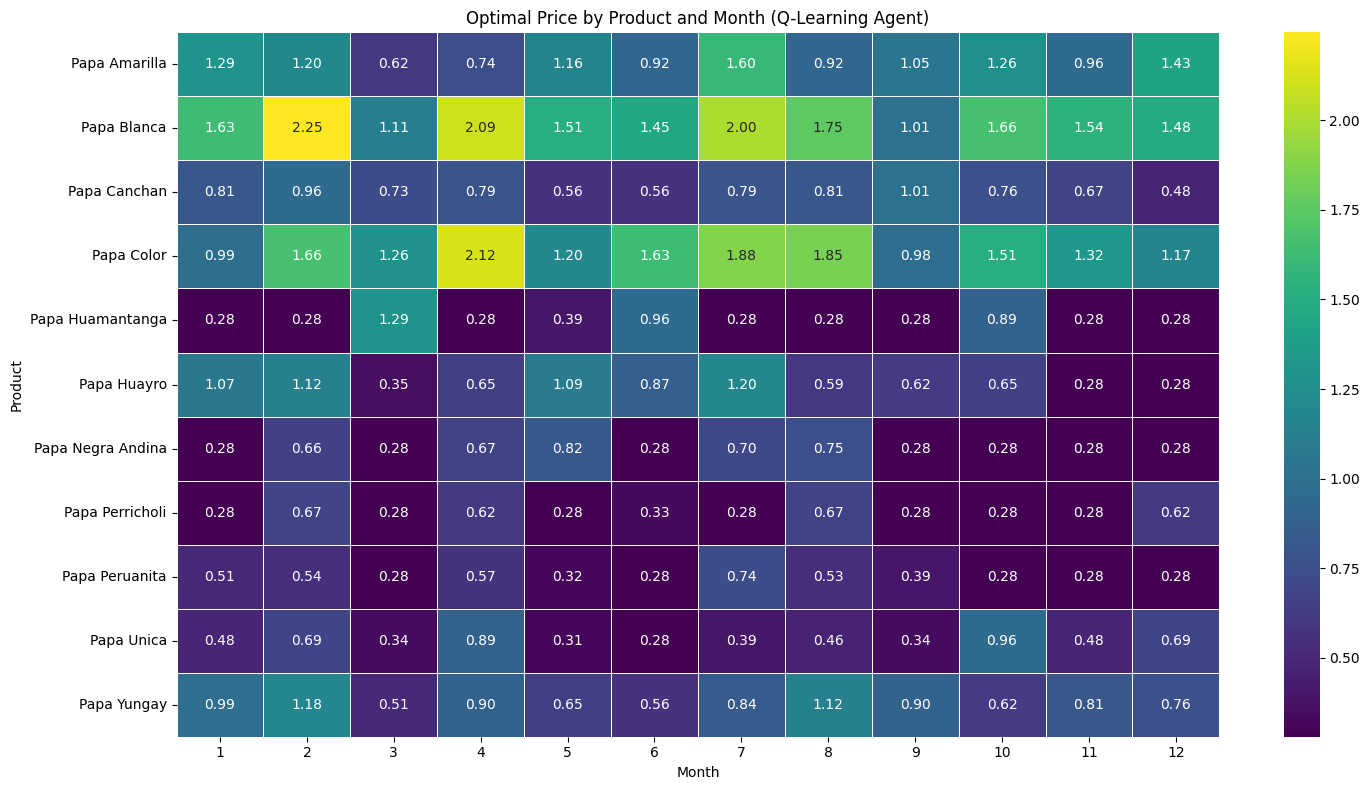

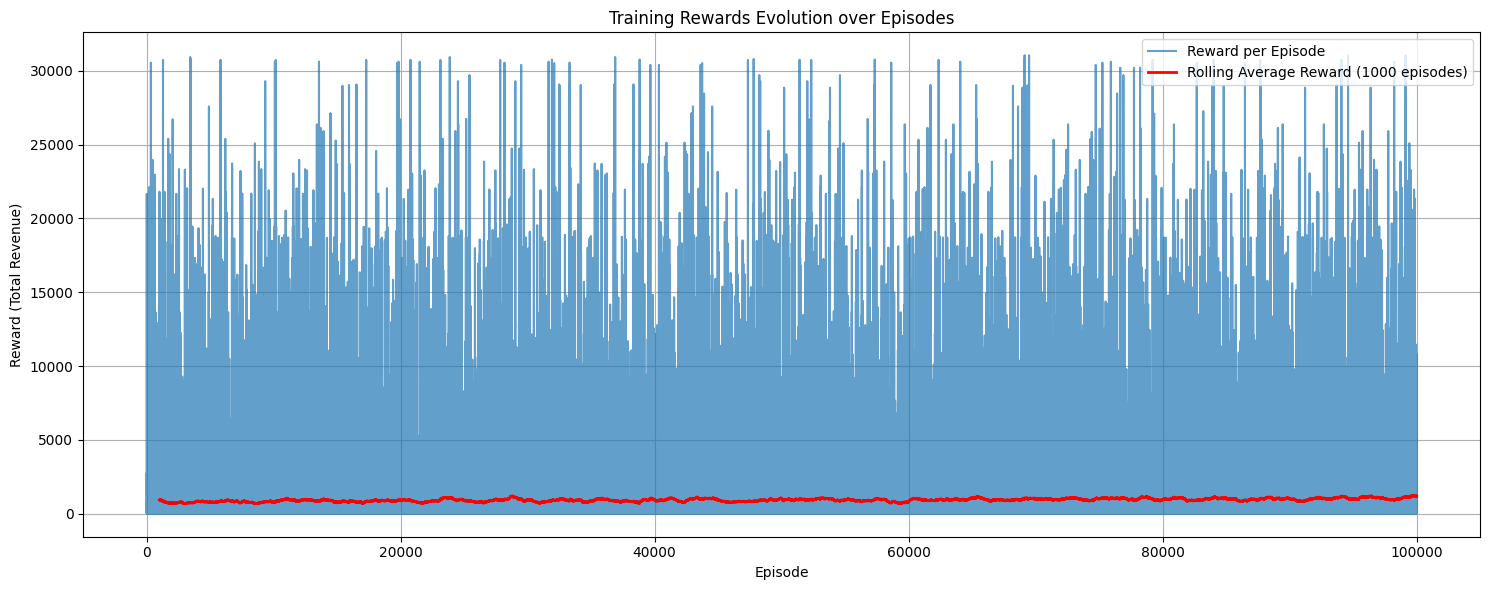

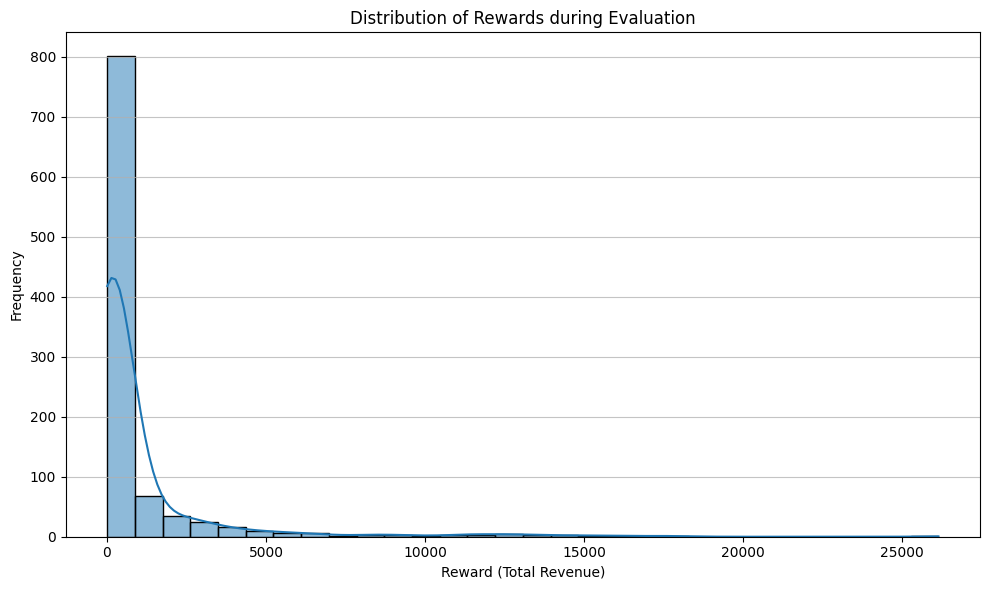

Visualizations of pricing policy and rewards generated.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize Optimal Price by Product and Month (Heatmap)
plt.figure(figsize=(15, 8))
# Pivot the policy_df for a heatmap: rows are products, columns are months
# Fill NaN values (for states not encountered) with a sensible default, e.g., median price or 0
pivot_table = policy_df.pivot_table(index='product', columns='mes', values='optimal_price')
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Optimal Price by Product and Month (Q-Learning Agent)')
plt.xlabel('Month')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# 2. Visualize Training Rewards Evolution
plt.figure(figsize=(15, 6))
plt.plot(rewards_per_episode, label='Reward per Episode', alpha=0.7)
plt.title('Training Rewards Evolution over Episodes')
plt.xlabel('Episode')
plt.ylabel('Reward (Total Revenue)')
plt.grid(True)
# Optionally, plot a rolling average for smoother trend visualization
rolling_avg_window = 1000
if len(rewards_per_episode) >= rolling_avg_window:
    rolling_avg = pd.Series(rewards_per_episode).rolling(window=rolling_avg_window).mean()
    plt.plot(rolling_avg, label=f'Rolling Average Reward ({rolling_avg_window} episodes)', color='red', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Visualize Distribution of Evaluation Rewards (Histogram/Boxplot)
plt.figure(figsize=(10, 6))
sns.histplot(eval_rewards, kde=True, bins=30)
plt.title('Distribution of Rewards during Evaluation')
plt.xlabel('Reward (Total Revenue)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print("Visualizations of pricing policy and rewards generated.")


## Resumen Final

### Subtask:
Proporcionar un resumen del rendimiento del agente de RL, las conclusiones clave de la evaluación y la efectividad general de la estrategia de precios desarrollada.


## Generar Precios Promedio Históricos (Baseline)

### Subtask:
Calcular el precio promedio por `producto` y `mes` directamente de los datos históricos (`data_papa`) para crear una línea base de política de precios.


# Task
The main goal is to develop a dynamic pricing strategy for agricultural products using Reinforcement Learning (RL). This involves defining an RL environment with appropriate state, action, and reward spaces, modeling product demand to simulate the environment, selecting and training an RL algorithm, and finally evaluating the performance of the trained pricing agent.

**Reasoning**:
Group the `data_papa` DataFrame by 'producto' and 'mes' to calculate the average price for each combination, then display the head of the resulting DataFrame.



In [28]:
historical_avg_prices = data_papa.groupby(['producto', 'mes'])['precio'].mean().reset_index()
print("Historical Average Prices (Baseline) by Product and Month:")
print(historical_avg_prices.head())

Historical Average Prices (Baseline) by Product and Month:
        producto  mes    precio
0  Papa Amarilla    1  1.358807
1  Papa Amarilla    2  1.351274
2  Papa Amarilla    3  1.321799
3  Papa Amarilla    4  1.231179
4  Papa Amarilla    5  1.149661


## Visualizar Precios Promedio Históricos (Baseline)

### Subtask:
Generar un mapa de calor (heatmap) que muestre los precios promedio históricos por producto y mes. Esta visualización servirá como una línea base para comparar con la política de precios aprendida por el agente de RL.


**Reasoning**:
Pivot the `historical_avg_prices` DataFrame and create a heatmap to visualize the historical average prices by product and month. This directly addresses the first two instructions of the subtask.



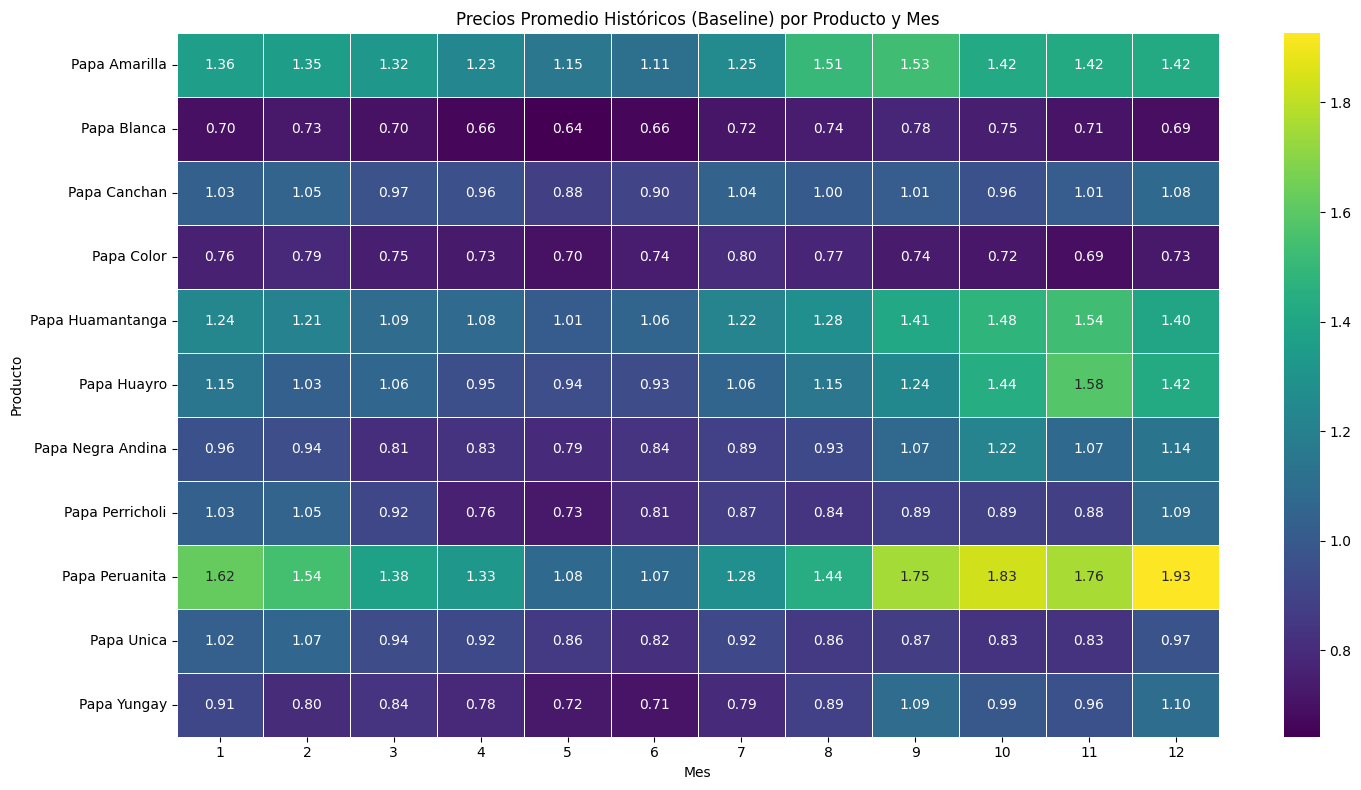

Heatmap of historical average prices generated.


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pivote el DataFrame para que 'producto' esté en el índice, 'mes' en las columnas y 'precio' como los valores.
# 2. Genere un mapa de calor utilizando seaborn.heatmap.
plt.figure(figsize=(15, 8))
pivot_historical = historical_avg_prices.pivot_table(index='producto', columns='mes', values='precio')
sns.heatmap(pivot_historical, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Precios Promedio Históricos (Baseline) por Producto y Mes')
plt.xlabel('Mes')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

print("Heatmap of historical average prices generated.")

## Visualizar la Política de Precios Aprendida por el Agente RL y Recompensas

### Subtask:
Generar gráficos para visualizar la política de precios aprendida por el agente de RL en estados clave (por ejemplo, cómo varía el precio por producto y mes) y mostrar la evolución de las recompensas durante el entrenamiento y la evaluación.


## Resumen Final y Comparación

### Subtask:
Proporcionar un resumen del rendimiento del agente de RL, las conclusiones clave de la evaluación, y una comparación directa entre la estrategia de precios aprendida por el agente de RL y la política de precios promedio histórica (baseline) para demostrar el valor añadido del RL.
